In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nahidwin2k11/nahnah/1-16923751486101295684318.jpg
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_5250.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_14143.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_23350.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_22654.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_126.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_2854.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset/N/pic_17486.png
/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-pla

In [2]:
!nvidia-smi

Sat Jul  4 13:45:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics roboflow imutils
!pip uninstall -y ray

# Tesseract engine (thường Kaggle đã có sẵn; dòng này để chắc chắn)
!apt-get install -y tesseract-ocr -q
!pip install -q pytesseract

print("\n✅ Cài xong. Không cần restart, chạy tiếp các cell.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.2 MB/s eta 0:00:00:00:01
Found existing installation: ray 2.55.1
Uninstalling ray-2.55.1:
  Successfully uninstalled ray-2.55.1
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 124 not upgraded.

✅ Cài xong. Không cần restart, chạy tiếp các cell.


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="tTkTiUk9TrCtl3GOIQGE")
project = rf.workspace("kiens-workspace-rr2ju").project("thewin")
version = project.version(2)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to thewin-2 in yolov8:: 100%|██████████| 3218/3218 [00:00<00:00, 7613.73it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
from ultralytics import YOLO


# Sử dụng mô hình mẫu yolov8n.pt để bắt đầu huấn luyện
model = YOLO('yolov8n.pt') 

# Huấn luyện mô hình với dữ liệu của bạn
model.train(data=f"{dataset.location}/data.yaml", epochs=100, imgsz=640, device=[0,1])

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/thewin-2/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nb

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:99: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.5it/s 2.2s.1ss
                   all        316        316      0.922      0.269      0.803      0.532

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      1.31G      1.215      1.729      1.173          7        640: 100% ━━━━━━━━━━━━ 71/71 6.1it/s 11.7s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 7.9it/s 1.3s.1s
                   all        316        316      0.874      0.843      0.921      0.608

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      1.31G      1.251      1.562      1.231          8        640: 100% ━━━━━━━━━━━━ 71/71 6.2it/s 11.4s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 8.2it/s 1.2s.1s
                   all        3

{'metrics/precision(B)': 0.99483,
 'metrics/recall(B)': 0.99724,
 'metrics/mAP50(B)': 0.99309,
 'metrics/mAP50-95(B)': 0.83085,
 'val/box_loss': 0.67768,
 'val/cls_loss': 0.32994,
 'val/dfl_loss': 0.91909,
 'fitness': 0.83085}

In [6]:
# DỌN ảnh cũ để không bị nhân đôi (chạy cell này trước khi Detect)
import shutil
shutil.rmtree('/kaggle/working/extracted_license_plates', ignore_errors=True)
shutil.rmtree('/kaggle/working/segmented_characters', ignore_errors=True)
print("✅ Đã dọn sạch ảnh cũ")

✅ Đã dọn sạch ảnh cũ


In [ ]:
# Xác định vùng chứa biển số xe
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Tải mô hình đã huấn luyện
model = YOLO('runs/detect/train/weights/best.pt')

def detect_license_plates(image_path, conf_threshold=0.5):
    """
    Xác định vùng chứa biển số xe trong hình ảnh
    
    Args:
        image_path (str): Đường dẫn đến hình ảnh
        conf_threshold (float): Ngưỡng độ tin cậy (0-1)
    
    Returns:
        results: Kết quả dự đoán từ YOLO
        image: Hình ảnh gốc
    """
    # Đọc hình ảnh
    image = cv2.imread(image_path)
    if image is None:   # ⭐ FIX: báo lỗi rõ ràng thay vì crash khó hiểu ở cvtColor
        raise FileNotFoundError(
            f"Không đọc được ảnh: {image_path}\n"
            f"-> Kiểm tra: (1) dataset chứa ảnh đã được Add Input chưa, "
            f"(2) tên file/đường dẫn có đúng chính tả (hoa/thường) không."
        )
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Thực hiện dự đoán
    results = model.predict(
        image_path, conf=conf_threshold,
        iou=0.45, agnostic_nms=True,   # ⭐ FIX: NMS xuyên lớp (0 = 2 hàng / 1 = 1 hàng)
                                        #        để không giữ 2 box chồng nhau cho cùng 1 biển
        verbose=False)
    
    return results[0], image_rgb, image

def visualize_detections(results, image_rgb):
    """
    Hiển thị hình ảnh với các vùng biển số xe được phát hiện
    """
    # Lấy tọa độ các vùng phát hiện
    annotated_frame = results.plot(conf=True)  # plot with confidence
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame)
    plt.title('Kết quả Xác định Biển số Xe')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return annotated_frame

def extract_license_plates(results, image):
    """Trích xuất các vùng biển số xe từ hình ảnh (kèm loại biển)"""
    license_plates = []
    if results.boxes is not None:
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            license_plate = image[y1:y2, x1:x2]
            confidence = float(box.conf[0])
            cls_id = int(box.cls[0])          # ⭐ 0 = 1 hàng, 1 = 2 hàng (theo data.yaml: names: [bien so 1 hang, bien so 2 hang])
            license_plates.append({
                'image': license_plate,
                'bbox': (x1, y1, x2, y2),
                'confidence': confidence,
                'class_id': cls_id            # ⭐ lưu loại biển
            })
    return license_plates

def save_license_plates(license_plates, output_dir='extracted_license_plates'):
    """
    Lưu các biển số xe được trích xuất vào thư mục
    
    Args:
        license_plates (list): Danh sách các biển số xe trích xuất
        output_dir (str): Đường dẫn thư mục đầu ra
    """
    # Tạo thư mục nếu chưa tồn tại
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    if len(license_plates) == 0:
        print('Không có biển số xe để lưu')
        return
    
    saved_files = []
    
    for idx, plate_data in enumerate(license_plates):
        # Tạo tên file với thông tin độ tin cậy
        confidence = plate_data['confidence']
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        cls_id = plate_data.get('class_id', 1)   # mặc định 1 hàng nếu thiếu
        filename = f"plate_{idx+1}_type{cls_id}_conf_{confidence:.2f}_{timestamp}.jpg"
        filepath = output_path / filename
        
        # Lưu hình ảnh
        cv2.imwrite(str(filepath), plate_data['image'])
        saved_files.append(filepath)
        
        print(f"✓ Đã lưu: {filename}")
    
    print(f"\n✓ Tổng cộng {len(saved_files)} biển số xe đã được lưu vào thư mục: {output_path.absolute()}")
    
    return saved_files

def display_extracted_plates(license_plates):
    """
    Hiển thị các biển số xe được trích xuất
    """
    if len(license_plates) == 0:
        print('Không tìm thấy biển số xe')
        return
    
    n_plates = len(license_plates)
    fig, axes = plt.subplots(1, n_plates, figsize=(5*n_plates, 5))
    
    if n_plates == 1:
        axes = [axes]
    
    for idx, plate_data in enumerate(license_plates):
        plate_rgb = cv2.cvtColor(plate_data['image'], cv2.COLOR_BGR2RGB)
        axes[idx].imshow(plate_rgb)
        axes[idx].set_title(f"Biển số {idx+1}\nĐộ tin cậy: {plate_data['confidence']:.2f}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# ============= PHẦN SỬ DỤNG =============
# Ví dụ: Sử dụng hàm với một hình ảnh
results, image_rgb, image_bgr = detect_license_plates('/kaggle/input/datasets/nahidwin2k11/nahnah/1-16923751486101295684318.jpg')
print(f'Tìm thấy {len(results.boxes)} biển số xe')

visualize_detections(results, image_rgb)

license_plates = extract_license_plates(results, image_bgr)

display_extracted_plates(license_plates)

# ⭐ THÊM DÒNG NÀY ĐỂ LƯU CÁC BIỂN SỐ XE VÀO THƯ MỤC
save_license_plates(license_plates, output_dir='extracted_license_plates')


🔤 CELL 3: SEGMENT KÍ TỰ BIỂN SỐ XE

📋 Kiểm tra output từ Cell Detection...
✅ Tìm thấy: /kaggle/working/extracted_license_plates
✅ Tìm thấy 8 ảnh biển số


[1/8] plate_7_type0_conf_0.75_20260704_140812.jpg
📊 Kích thước: 295x56px
✅ Tách được 9 kí tự:
   #0: W=  8 H= 39 AR=0.205 Sol=0.524
   #1: W= 24 H= 41 AR=0.585 Sol=0.341
   #2: W= 26 H= 41 AR=0.634 Sol=0.355
   #3: W= 26 H= 42 AR=0.619 Sol=0.443
   #4: W= 25 H= 41 AR=0.610 Sol=0.384
   #5: W= 25 H= 41 AR=0.610 Sol=0.339
   #6: W= 27 H= 41 AR=0.659 Sol=0.392
   #7: W= 29 H= 40 AR=0.725 Sol=0.550
   #8: W= 24 H= 41 AR=0.585 Sol=0.323
💾 Lưu vào: /kaggle/working/segmented_characters/plate_7_type0_conf_0.75_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


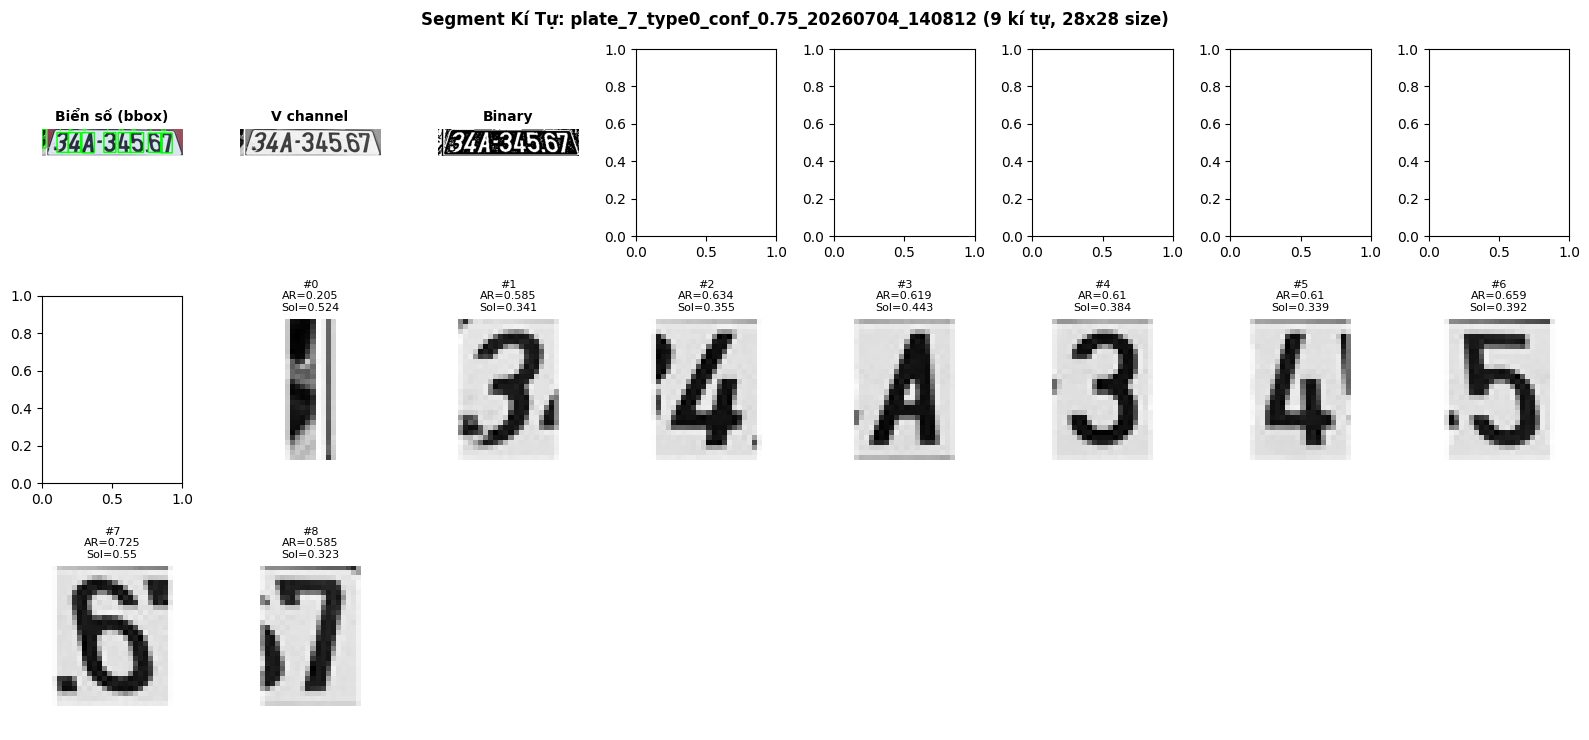


[2/8] plate_3_type0_conf_0.90_20260704_140812.jpg
📊 Kích thước: 194x82px
✅ Tách được 9 kí tự:
   #0: W= 20 H= 33 AR=0.606 Sol=0.617
   #1: W= 19 H= 33 AR=0.576 Sol=0.649
   #2: W= 19 H= 33 AR=0.576 Sol=0.640
   #3: W= 20 H= 33 AR=0.606 Sol=0.608
   #4: W= 21 H= 34 AR=0.618 Sol=0.244
   #5: W= 17 H= 34 AR=0.500 Sol=0.401
   #6: W= 21 H= 34 AR=0.618 Sol=0.299
   #7: W= 12 H= 44 AR=0.273 Sol=0.291
   #8: W= 20 H= 33 AR=0.606 Sol=0.272
💾 Lưu vào: /kaggle/working/segmented_characters/plate_3_type0_conf_0.90_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


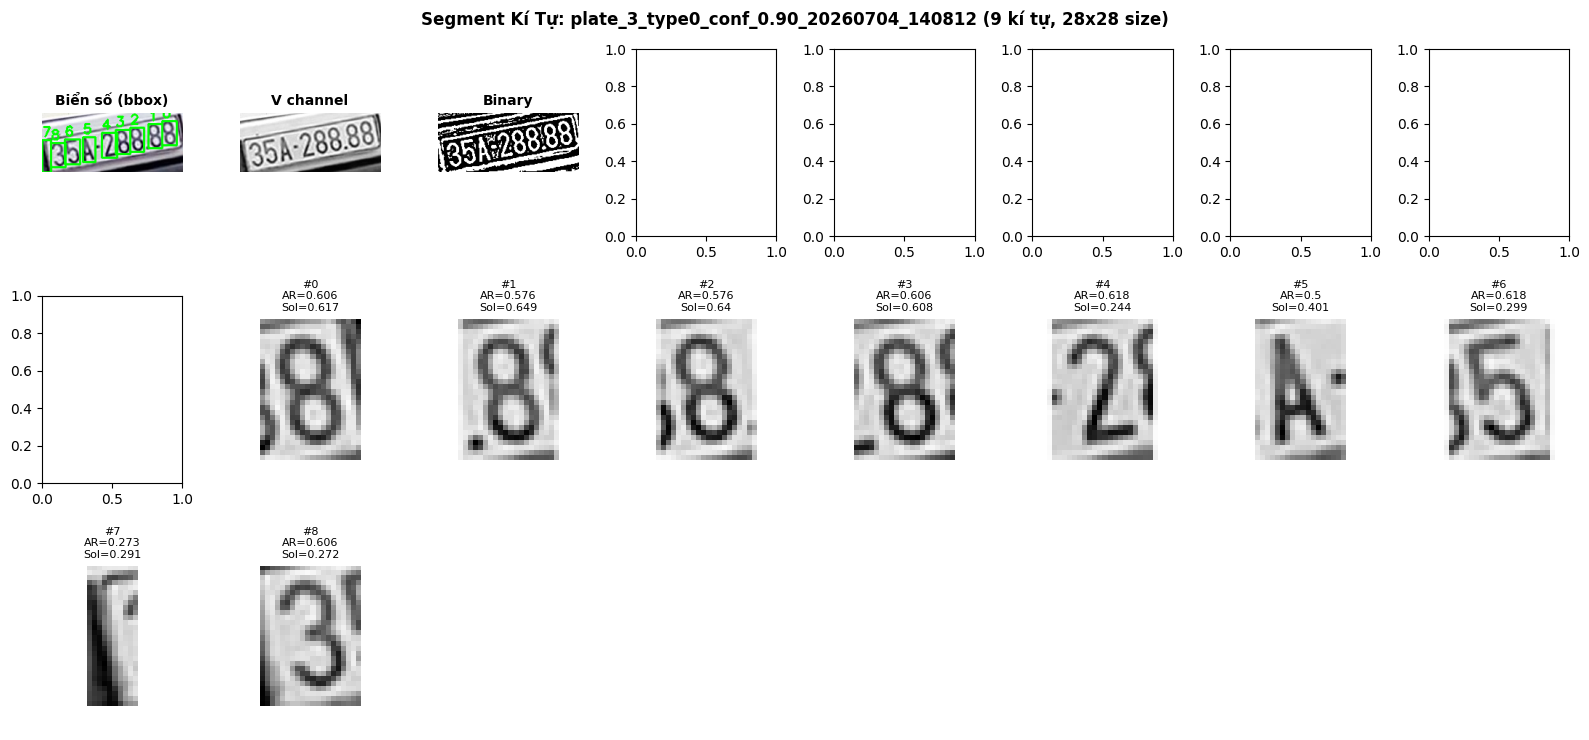


[3/8] plate_6_type0_conf_0.87_20260704_140812.jpg
📊 Kích thước: 133x41px
✅ Tách được 8 kí tự:
   #0: W= 13 H= 23 AR=0.565 Sol=0.283
   #1: W=  6 H= 23 AR=0.261 Sol=0.326
   #2: W= 10 H= 23 AR=0.435 Sol=0.465
   #3: W= 13 H= 23 AR=0.565 Sol=0.264
   #4: W= 12 H= 23 AR=0.522 Sol=0.665
   #5: W= 13 H= 23 AR=0.565 Sol=0.522
   #6: W= 12 H= 23 AR=0.522 Sol=0.696
   #7: W= 12 H= 23 AR=0.522 Sol=0.701
💾 Lưu vào: /kaggle/working/segmented_characters/plate_6_type0_conf_0.87_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


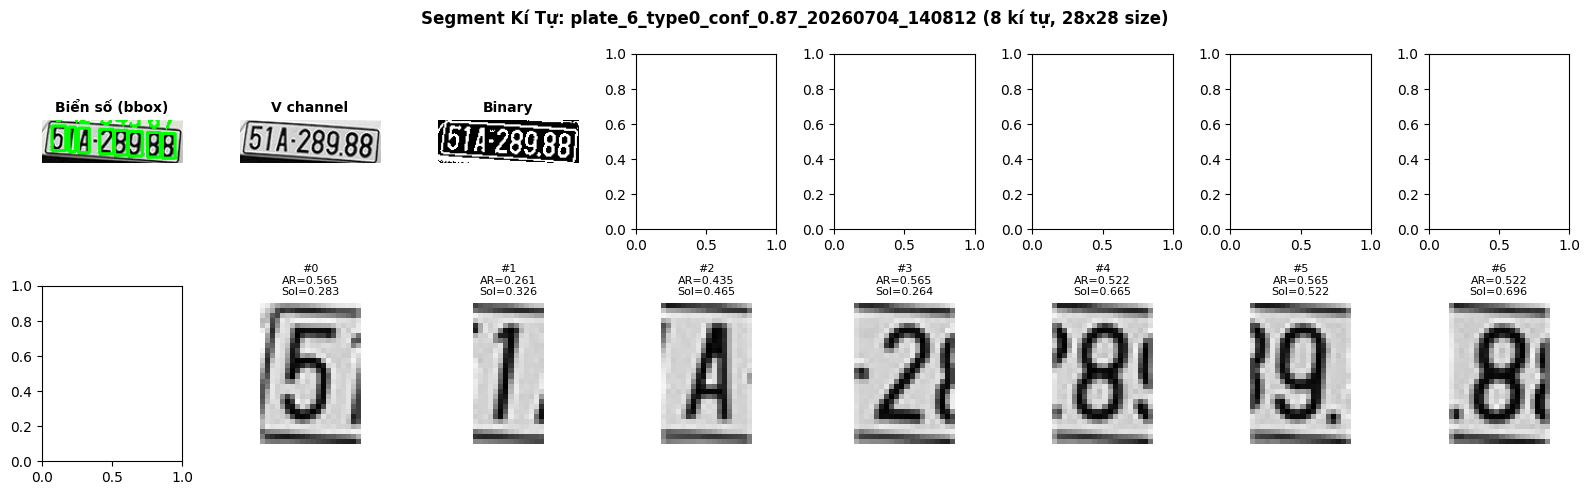


[4/8] plate_5_type1_conf_0.89_20260704_140812.jpg
📊 Kích thước: 114x81px
✅ Tách được 8 kí tự:
   #0: W= 18 H= 30 AR=0.600 Sol=0.323
   #1: W= 18 H= 30 AR=0.600 Sol=0.541
   #2: W= 18 H= 29 AR=0.621 Sol=0.294
   #3: W= 17 H= 30 AR=0.567 Sol=0.563
   #4: W= 17 H= 30 AR=0.567 Sol=0.586
   #5: W= 17 H= 30 AR=0.567 Sol=0.587
   #6: W= 18 H= 30 AR=0.600 Sol=0.574
   #7: W= 18 H= 31 AR=0.581 Sol=0.573
💾 Lưu vào: /kaggle/working/segmented_characters/plate_5_type1_conf_0.89_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


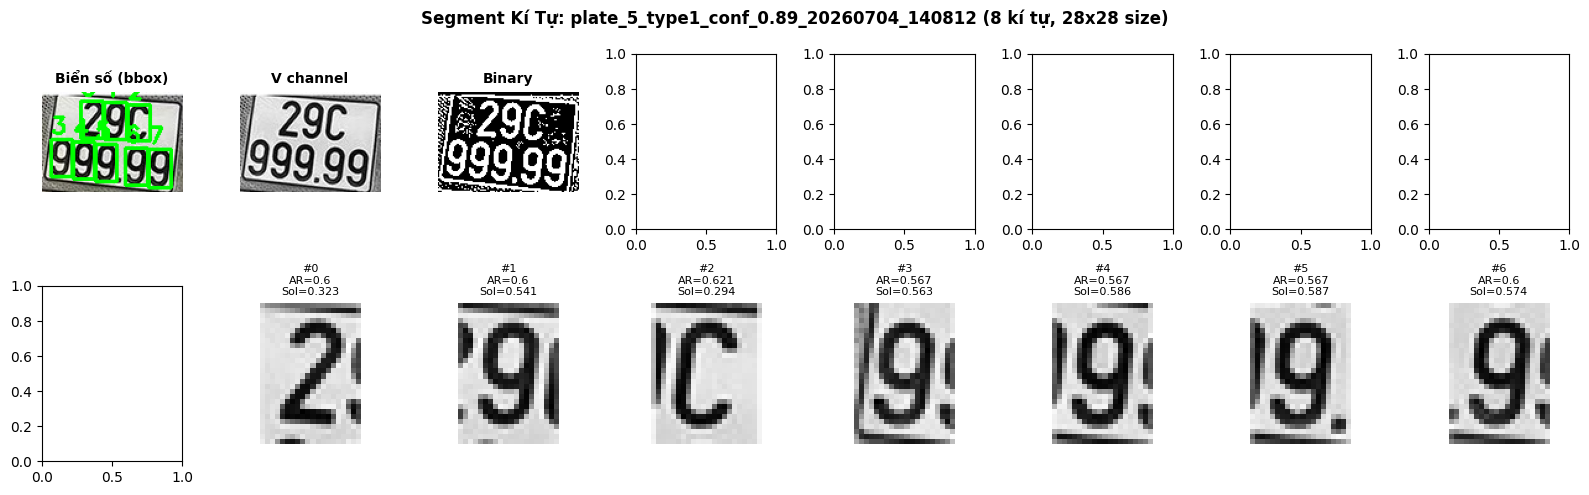


[5/8] plate_1_type0_conf_0.91_20260704_140812.jpg
📊 Kích thước: 223x61px
✅ Tách được 8 kí tự:
   #0: W= 18 H= 35 AR=0.514 Sol=0.648
   #1: W= 19 H= 35 AR=0.543 Sol=0.787
   #2: W= 18 H= 37 AR=0.486 Sol=0.483
   #3: W= 20 H= 35 AR=0.571 Sol=0.625
   #4: W= 20 H= 36 AR=0.556 Sol=0.615
   #5: W= 20 H= 35 AR=0.571 Sol=0.631
   #6: W= 20 H= 35 AR=0.571 Sol=0.642
   #7: W= 20 H= 36 AR=0.556 Sol=0.620
💾 Lưu vào: /kaggle/working/segmented_characters/plate_1_type0_conf_0.91_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


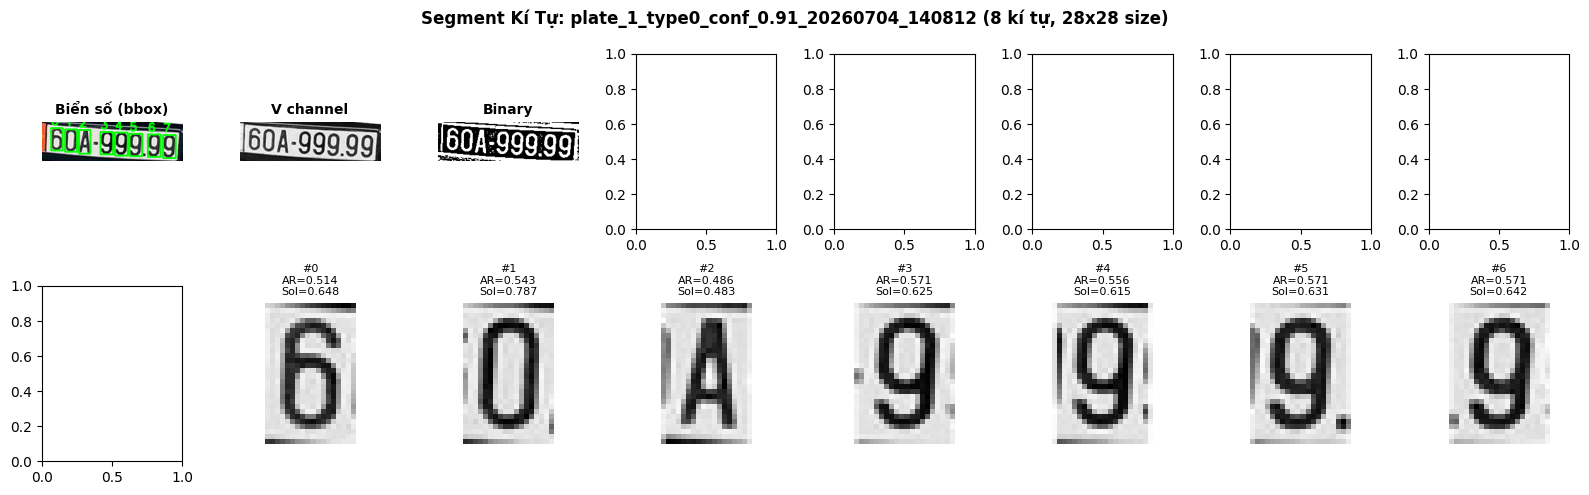


[6/8] plate_4_type0_conf_0.90_20260704_140812.jpg
📊 Kích thước: 197x69px
✅ Tách được 8 kí tự:
   #0: W= 18 H= 31 AR=0.581 Sol=0.674
   #1: W= 18 H= 31 AR=0.581 Sol=0.684
   #2: W= 19 H= 31 AR=0.613 Sol=0.544
   #3: W= 19 H= 31 AR=0.613 Sol=0.551
   #4: W= 19 H= 31 AR=0.613 Sol=0.649
   #5: W= 16 H= 33 AR=0.485 Sol=0.263
   #6: W= 12 H= 32 AR=0.375 Sol=0.246
   #7: W= 20 H= 32 AR=0.625 Sol=0.266
💾 Lưu vào: /kaggle/working/segmented_characters/plate_4_type0_conf_0.90_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


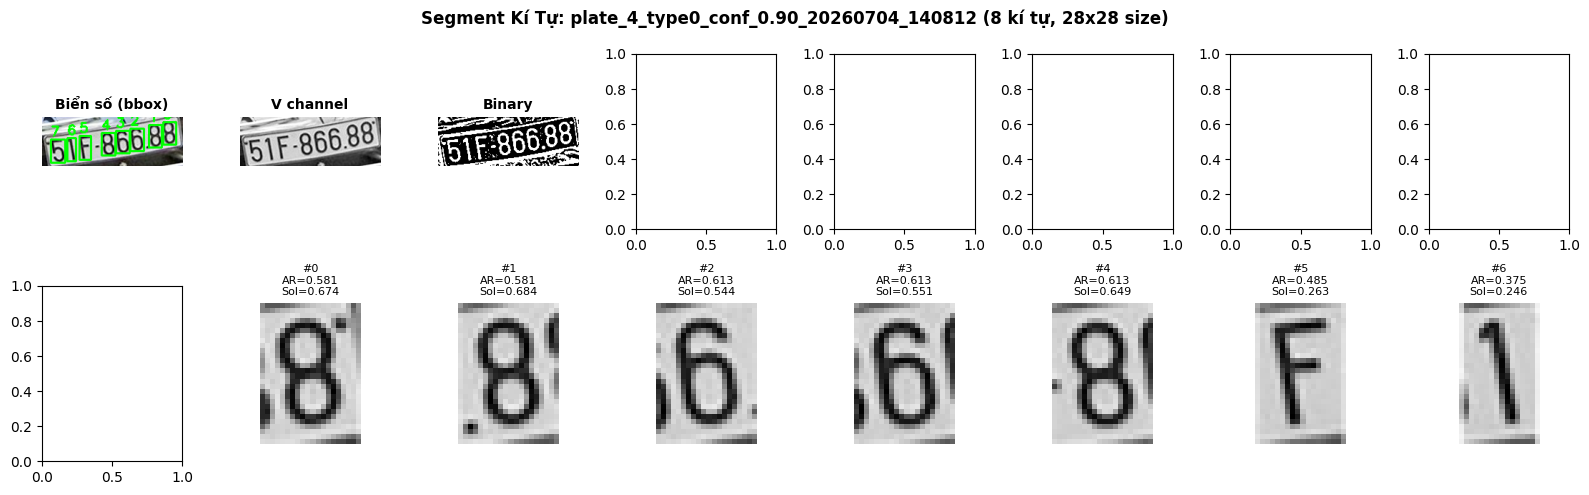


[7/8] plate_8_type0_conf_0.75_20260704_140812.jpg
📊 Kích thước: 203x60px
✅ Tách được 9 kí tự:
   #0: W=  4 H= 30 AR=0.133 Sol=0.279
   #1: W= 19 H= 31 AR=0.613 Sol=0.295
   #2: W= 18 H= 31 AR=0.581 Sol=0.547
   #3: W= 18 H= 31 AR=0.581 Sol=0.291
   #4: W= 18 H= 31 AR=0.581 Sol=0.551
   #5: W= 18 H= 31 AR=0.581 Sol=0.587
   #6: W= 18 H= 31 AR=0.581 Sol=0.601
   #7: W= 18 H= 32 AR=0.562 Sol=0.588
   #8: W= 18 H= 33 AR=0.545 Sol=0.589
💾 Lưu vào: /kaggle/working/segmented_characters/plate_8_type0_conf_0.75_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


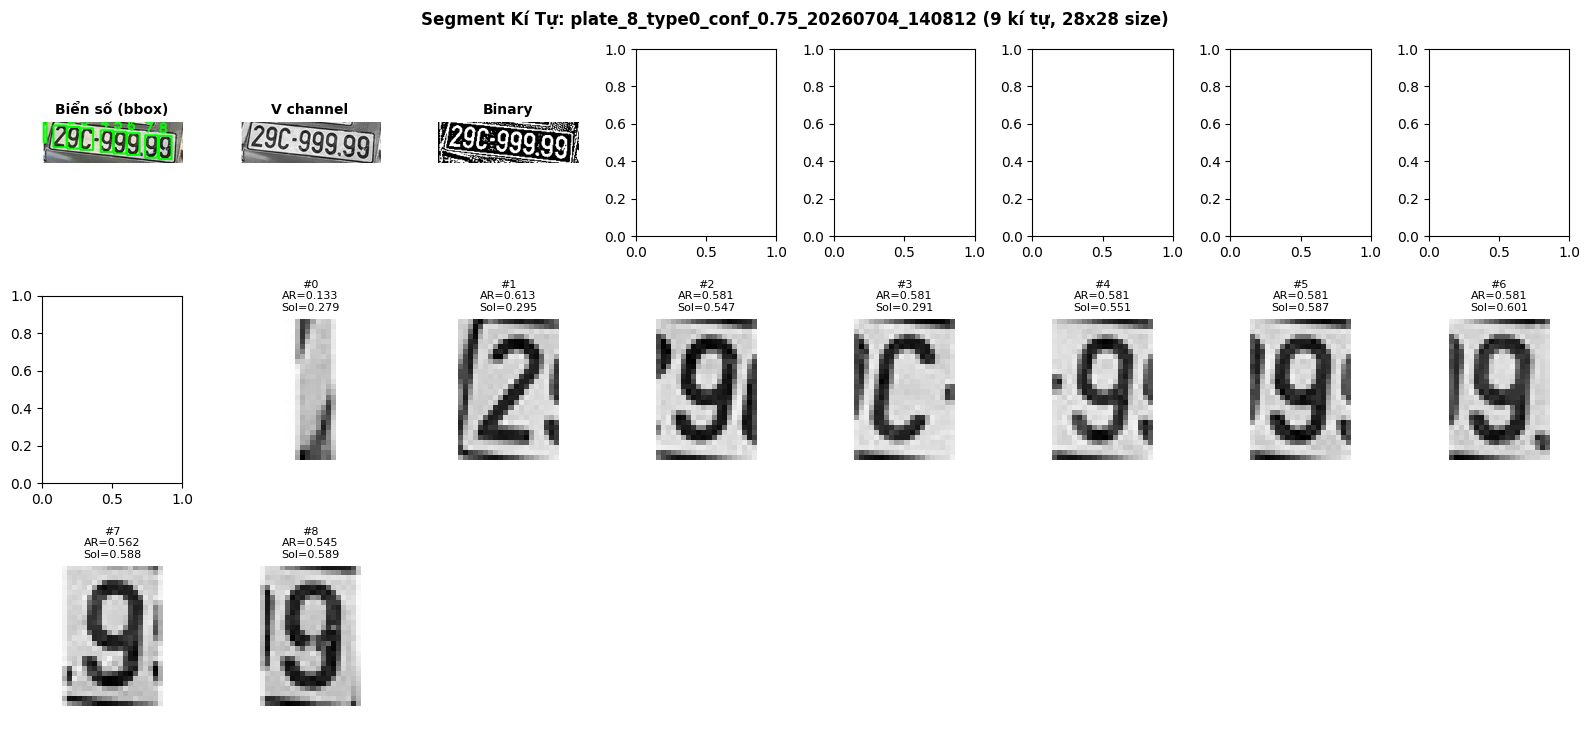


[8/8] plate_2_type1_conf_0.90_20260704_140812.jpg
📊 Kích thước: 145x76px
✅ Tách được 6 kí tự:
   #0: W= 19 H= 27 AR=0.704 Sol=0.319
   #1: W= 24 H= 32 AR=0.750 Sol=0.349
   #2: W= 22 H= 32 AR=0.688 Sol=0.335
   #3: W= 21 H= 32 AR=0.656 Sol=0.406
   #4: W= 22 H= 31 AR=0.710 Sol=0.614
   #5: W= 21 H= 31 AR=0.677 Sol=0.301
💾 Lưu vào: /kaggle/working/segmented_characters/plate_2_type1_conf_0.90_20260704_140812/
   (Kích thước: 28x28 pixels, Grayscale)
📊 Hiển thị...


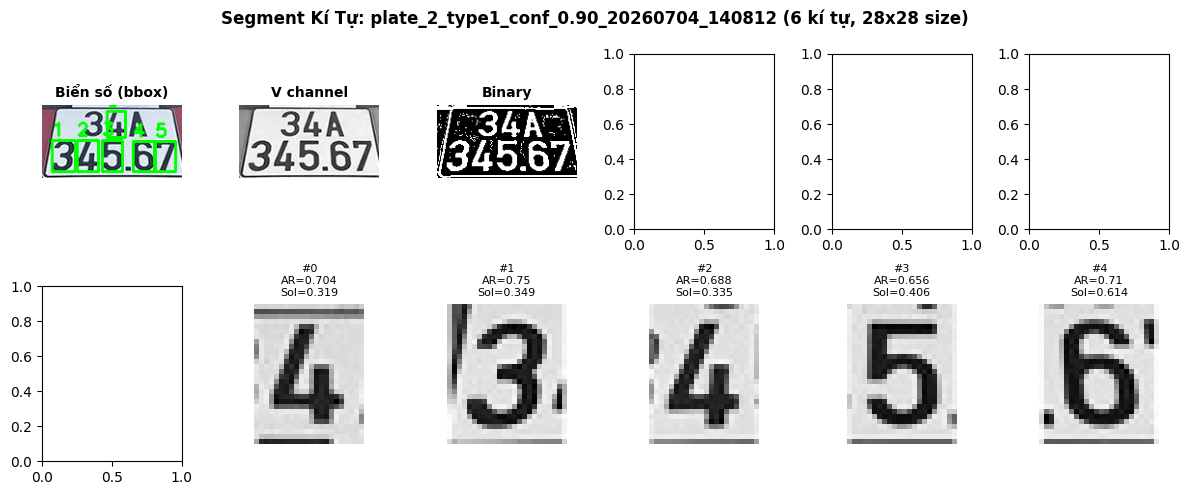


✅ HOÀN THÀNH SEGMENT

📊 THỐNG KÊ:
   • Tổng ảnh biển số: 8
   • Tổng kí tự tách được: 65
   • Kích thước mỗi kí tự: 28x28 pixels (Grayscale)
   • Output: /kaggle/working/segmented_characters/

✨ Kí tự đã sẵn sàng để:
   ✅ Feed vào CNN (dạng 28x28x1)
   ✅ Áp dụng OCR
   ✅ Huấn luyện classifier

📝 Ghi chú:
   • Phương pháp: HSV V-channel + Adaptive Threshold + CCA
   • Tiêu chí lọc: AR(0.1-1.0), Solidity(>0.1), HR(0.35-2.0)
   • Resize: 28x28 Grayscale (chuẩn bị cho CNN)


In [8]:
# ============================================================================
# CELL 3: SEGMENT - TÁCH KÍ TỰ TỪ BIỂN SỐ XE (ĐÃ SỬA FIX)
# ============================================================================
# Dựa trên phương pháp cũ (5 năm):
#  - BGR → HSV → V channel (Value/độ sáng)
#  - Adaptive Threshold
#  - Connected Components Analysis (CCA)
#  - Filter: aspect_ratio, solidity, height_ratio
#  - Extract & resize 28x28
# 
# Liên kết tự động với Cell Detection
# ============================================================================

import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("🔤 CELL 3: SEGMENT KÍ TỰ BIỂN SỐ XE")
print("="*70 + "\n")

# ============================================================================
# KIỂM TRA DETECTION OUTPUT
# ============================================================================

detected_labels_dir = '/kaggle/working/extracted_license_plates'

print("📋 Kiểm tra output từ Cell Detection...")
if not os.path.exists(detected_labels_dir):
    print(f"❌ LỖI: Không tìm thấy {detected_labels_dir}")
    print(f"⚠️  Hãy chạy Cell Detection (YOLO) trước!")
else:
    print(f"✅ Tìm thấy: {detected_labels_dir}")

# Tìm ảnh biển số
plate_images = []
for root, dirs, files in os.walk(detected_labels_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            plate_images.append({
                'path': os.path.join(root, file),
                'name': file,
                'class': os.path.basename(root)
            })

print(f"✅ Tìm thấy {len(plate_images)} ảnh biển số\n")

if len(plate_images) == 0:
    print("❌ KHÔNG CÓ ẢNH BIỂN SỐ! Hãy chạy Cell Detection trước.")
else:
    # ============================================================================
    # CLASS SEGMENTER - SỬ DỤNG PHƯƠNG PHÁP CŨ (HSV + CCA)
    # ============================================================================
    
    class LicensePlateCharacterSegmenter:
        """
        Segment kí tự từ biển số xe
        Phương pháp: BGR → HSV → V channel → Adaptive Threshold → CCA
        """
        
        def __init__(self, output_dir='/kaggle/working/segmented_characters'):
            self.output_dir = output_dir
            os.makedirs(output_dir, exist_ok=True)
            self.all_candidates = []
        
        def preprocess_using_hsv_v_channel(self, image):
            """
            Tiền xử lý sử dụng HSV V channel (như code cũ)
            
            Args:
                image: ảnh BGR
            
            Returns:
                V: Value channel
            """
            # Chuyển BGR → HSV
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
            
            # Tách V channel (độ sáng/brightness)
            V = cv2.split(hsv)[2]
            
            return V
        
        def adaptive_threshold_gaussian(self, V):
            """
            Áp dụng Adaptive Threshold (như code cũ)
            Sử dụng Gaussian method
            
            Args:
                V: Value channel
            
            Returns:
                binary: ảnh nhị phân
            """
            binary = cv2.adaptiveThreshold(
                V,
                255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                blockSize=15,  # Kích thước lân cận (từ code cũ: 15)
                C=2             # Hằng số trừ đi
            )
            
            # Đảo màu: chữ trắng (255), nền đen (0)
            binary = cv2.bitwise_not(binary)
            
            return binary
        
        def cca_connected_components(self, binary):
            """
            Connected Components Analysis (CCA) - như code cũ
            
            Args:
                binary: ảnh nhị phân
            
            Returns:
                labels: mỗi pixel được gán nhãn
            """
            # Sử dụng cv2.connectedComponents
            num_labels, labels = cv2.connectedComponents(binary)
            
            return labels, num_labels
        
        def segment_characters(self, image):
            """
            Segment kí tự từ biển số
            
            Args:
                image: ảnh biển số
            
            Returns:
                candidates: danh sách kí tự 28x28
                info: thông tin chi tiết
            """
            
            # Bước 1: Tiền xử lý HSV V channel
            V = self.preprocess_using_hsv_v_channel(image)
            
            # Bước 2: Adaptive Threshold
            binary = self.adaptive_threshold_gaussian(V)
            
            # Bước 3: CCA (Connected Components Analysis)
            labels, num_labels = self.cca_connected_components(binary)
            
            # Lấy kích thước
            height, width = image.shape[:2]
            
            # Bước 4: Lọc từng component
            candidates = []
            char_info = []
            
            for label in np.unique(labels):
                # Bỏ qua background (label 0)
                if label == 0:
                    continue
                
                # Tạo mask cho label này
                mask = np.zeros(binary.shape, dtype="uint8")
                mask[labels == label] = 255
                
                # Tìm contours từ mask
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                if len(contours) == 0:
                    continue
                
                # Lấy contour lớn nhất
                contour = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(contour)
                
                # Tính bounding rect
                x, y, w, h = cv2.boundingRect(contour)
                
                # Tính các đặc trưng (3 tiêu chí từ code cũ)
                aspect_ratio = w / float(h) if h > 0 else 0
                solidity = area / (w * h) if (w * h) > 0 else 0
                height_ratio = h / float(height)
                
                # Tiêu chí lọc (từ code cũ)
                # if 0.1 < aspectRatio < 1.0 and solidity > 0.1 and 0.35 < heightRatio < 2.0:
                if (0.1 < aspect_ratio < 1.0 and 
                    solidity > 0.1 and 
                    0.35 < height_ratio < 2.0):
                    
                    # Crop kí tự
                    pad = 5
                    x_start = max(0, x - pad)
                    y_start = max(0, y - pad)
                    x_end = min(width, x + w + pad)
                    y_end = min(height, y + h + pad)
                    
                    candidate = image[y_start:y_end, x_start:x_end].copy()
                    
                    # Convert thành square (như code cũ: convertToSquare)
                    square_candidate = self.convert_to_square(candidate)
                    
                    # Resize 28x28 (như code cũ)
                    square_candidate = cv2.resize(square_candidate, (28, 28), interpolation=cv2.INTER_AREA)
                    
                    # ✅ FIX: Chuyển BGR → Grayscale
                    square_candidate = cv2.cvtColor(square_candidate, cv2.COLOR_BGR2GRAY)
                    
                    # Reshape (28, 28, 1) - chuẩn bị cho CNN
                    square_candidate = square_candidate.reshape((28, 28, 1))
                    
                    candidates.append(square_candidate)
                    char_info.append({
                        'index': len(candidates) - 1,
                        'x': x,
                        'y': y,
                        'w': w,
                        'h': h,
                        'area': int(area),
                        'aspect_ratio': round(aspect_ratio, 3),
                        'solidity': round(solidity, 3),
                        'height_ratio': round(height_ratio, 3)
                    })
            
            return candidates, char_info, binary, V
        
        def convert_to_square(self, image):
            """
            Chuyển ảnh hình chữ nhật thành hình vuông (như code cũ)
            """
            h, w = image.shape[:2]
            
            if h == w:
                return image
            
            # Padding để tạo vuông
            if w < h:
                # Hẹp hơn → padding ngang
                pad = (h - w) // 2
                image = cv2.copyMakeBorder(image, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=[255, 255, 255])
            else:
                # Rộng hơn → padding dọc
                pad = (w - h) // 2
                image = cv2.copyMakeBorder(image, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
            
            return image
        
        def save_candidates(self, candidates, plate_name):
            """Lưu các kí tự"""
            plate_dir = os.path.join(self.output_dir, plate_name)
            os.makedirs(plate_dir, exist_ok=True)
            
            for idx, candidate in enumerate(candidates):
                # ✅ candidate shape: (28, 28, 1) - Grayscale
                img_to_save = candidate.reshape(28, 28).astype('uint8')
                
                char_path = os.path.join(plate_dir, f"char_{idx:02d}.jpg")
                cv2.imwrite(char_path, img_to_save)
                
                self.all_candidates.append({
                    'plate': plate_name,
                    'index': idx,
                    'path': char_path,
                    'data': candidate
                })
        
        def visualize(self, image, V, binary, candidates, char_info, title):
            """Hiển thị kết quả"""
            
            # Vẽ bbox trên ảnh gốc
            image_with_boxes = image.copy()
            for info in char_info:
                x, y, w, h = info['x'], info['y'], info['w'], info['h']
                cv2.rectangle(image_with_boxes, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(image_with_boxes, str(info['index']), (x, y-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            num_chars = len(candidates)
            if num_chars == 0:
                return
            
            cols = min(8, max(num_chars, 2))
            rows = (num_chars + cols - 1) // cols
            
            fig, axes = plt.subplots(rows + 1, cols, figsize=(cols*2, (rows+1)*2.5))
            if isinstance(axes, np.ndarray):
                axes = axes.flatten()
            else:
                axes = [axes]
            
            # Hàng 1: Ảnh gốc + V channel + Binary
            axes[0].imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Biển số (bbox)", fontsize=10, fontweight='bold')
            axes[0].axis('off')
            
            if len(axes) > 1:
                axes[1].imshow(V, cmap='gray')
                axes[1].set_title("V channel", fontsize=10, fontweight='bold')
                axes[1].axis('off')
            
            if len(axes) > 2:
                axes[2].imshow(binary, cmap='gray')
                axes[2].set_title("Binary", fontsize=10, fontweight='bold')
                axes[2].axis('off')
            
            # ✅ Các kí tự (28x28) - Grayscale
            for idx, candidate in enumerate(candidates):
                ax_idx = idx + cols + 1
                if ax_idx < len(axes):
                    # candidate shape: (28, 28, 1)
                    img_display = candidate.reshape(28, 28).astype('uint8')
                    axes[ax_idx].imshow(img_display, cmap='gray')
                    info = char_info[idx]
                    axes[ax_idx].set_title(
                        f"#{idx}\nAR={info['aspect_ratio']}\nSol={info['solidity']}", 
                        fontsize=8
                    )
                    axes[ax_idx].axis('off')
            
            # Ẩn ô không dùng
            for idx in range(num_chars + cols + 1, len(axes)):
                axes[idx].axis('off')
            
            plt.suptitle(f"Segment Kí Tự: {title} ({num_chars} kí tự, 28x28 size)", 
                        fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    # ============================================================================
    # CHẠY SEGMENT
    # ============================================================================
    
    segmenter = LicensePlateCharacterSegmenter()
    
    total_chars = 0
    
    for idx, plate_info in enumerate(plate_images, 1):
        print(f"\n{'='*70}")
        print(f"[{idx}/{len(plate_images)}] {plate_info['name']}")
        print(f"{'='*70}")
        
        # Đọc ảnh
        image = cv2.imread(plate_info['path'])
        if image is None:
            print(f"❌ Lỗi: Không đọc được ảnh")
            continue
        
        print(f"📊 Kích thước: {image.shape[1]}x{image.shape[0]}px")
        
        # Segment
        candidates, char_info, binary, V = segmenter.segment_characters(image)
        
        if len(candidates) == 0:
            print(f"⚠️  Không tách được kí tự nào")
            continue
        
        print(f"✅ Tách được {len(candidates)} kí tự:")
        for info in char_info:
            print(f"   #{info['index']}: W={info['w']:3d} H={info['h']:3d} "
                  f"AR={info['aspect_ratio']:.3f} Sol={info['solidity']:.3f}")
        
        # Lưu
        plate_name = Path(plate_info['name']).stem
        segmenter.save_candidates(candidates, plate_name)
        
        total_chars += len(candidates)
        
        print(f"💾 Lưu vào: {segmenter.output_dir}/{plate_name}/")
        print(f"   (Kích thước: 28x28 pixels, Grayscale)")
        
        # Visualize
        print(f"📊 Hiển thị...")
        segmenter.visualize(image, V, binary, candidates, char_info, plate_name)
    
    # ============================================================================
    # THỐNG KÊ
    # ============================================================================
    
    print("\n" + "="*70)
    print("✅ HOÀN THÀNH SEGMENT")
    print("="*70)
    
    print(f"\n📊 THỐNG KÊ:")
    print(f"   • Tổng ảnh biển số: {len(plate_images)}")
    print(f"   • Tổng kí tự tách được: {total_chars}")
    print(f"   • Kích thước mỗi kí tự: 28x28 pixels (Grayscale)")
    print(f"   • Output: {segmenter.output_dir}/")
    
    print(f"\n✨ Kí tự đã sẵn sàng để:")
    print(f"   ✅ Feed vào CNN (dạng 28x28x1)")
    print(f"   ✅ Áp dụng OCR")
    print(f"   ✅ Huấn luyện classifier")
    
    print(f"\n📝 Ghi chú:")
    print(f"   • Phương pháp: HSV V-channel + Adaptive Threshold + CCA")
    print(f"   • Tiêu chí lọc: AR(0.1-1.0), Solidity(>0.1), HR(0.35-2.0)")
    print(f"   • Resize: 28x28 Grayscale (chuẩn bị cho CNN)")

Tìm thấy 8 ảnh biển số

🚗 plate_1_type0_conf_0.91_20260704_140812.jpg  [1 hàng]  ->  150A99999


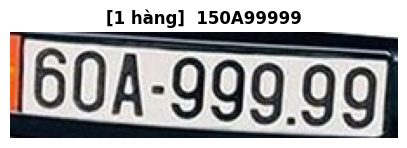

🚗 plate_2_type1_conf_0.90_20260704_140812.jpg  [2 hàng]  ->  3AAY134567


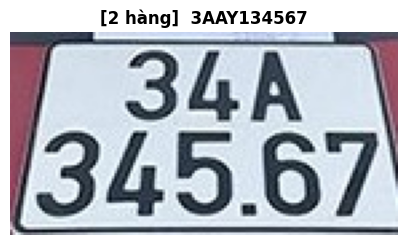

🚗 plate_3_type0_conf_0.90_20260704_140812.jpg  [1 hàng]  ->  AEK1R8


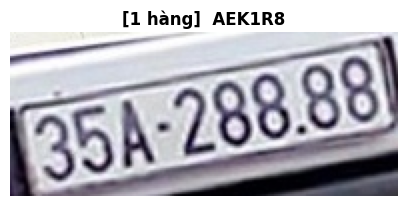

🚗 plate_4_type0_conf_0.90_20260704_140812.jpg  [1 hàng]  ->  F1F00688


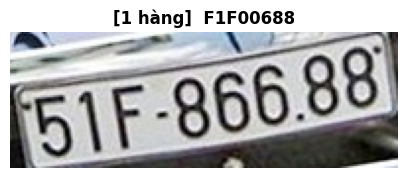

🚗 plate_5_type1_conf_0.89_20260704_140812.jpg  [2 hàng]  ->  129C99999


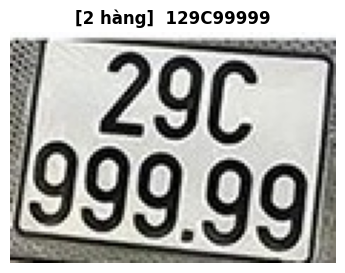

🚗 plate_6_type0_conf_0.87_20260704_140812.jpg  [1 hàng]  ->  91428988


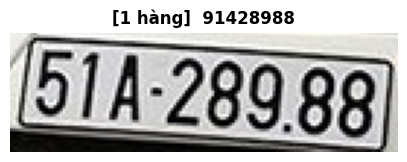

🚗 plate_7_type0_conf_0.75_20260704_140812.jpg  [1 hàng]  ->  V3LA345875


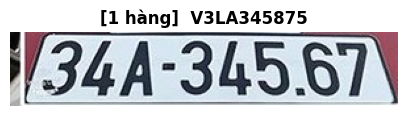

🚗 plate_8_type0_conf_0.75_20260704_140812.jpg  [1 hàng]  ->  429C99999


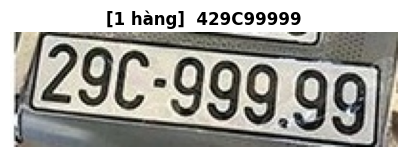

In [9]:
import os, re, cv2
import pytesseract
import matplotlib.pyplot as plt

VALID_CHARS = "ABCDEFGHKLMNPRSTUVXYZ0123456789"
OCR_CONFIG = '--psm 7 -c tessedit_char_whitelist=ABCDEFGHKLMNPRSTUVXYZ0123456789'

def clean(text):
    return "".join(ch for ch in text.upper() if ch in VALID_CHARS)

def preprocess(img):
    """Xám + phóng to + nhị phân Otsu để OCR rõ hơn."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def read_one_line(img):
    th = preprocess(img)
    return clean(pytesseract.image_to_string(th, config=OCR_CONFIG))

def read_plate(img, plate_type):
    """plate_type: '0' = 1 hàng, '1' = 2 hàng."""
    if plate_type == '1':
        # BIỂN 2 HÀNG -> cắt đôi trên/dưới, đọc riêng, ghép lại
        h = img.shape[0]
        top    = img[:int(h*0.52), :]
        bottom = img[int(h*0.48):, :]
        return read_one_line(top) + read_one_line(bottom)
    else:
        # BIỂN 1 HÀNG -> đọc thẳng
        return read_one_line(img)

PLATES_DIR = '/kaggle/working/extracted_license_plates'

plate_files = []
for root, _, files in os.walk(PLATES_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            plate_files.append(os.path.join(root, f))
plate_files.sort()

print(f"Tìm thấy {len(plate_files)} ảnh biển số\n")

for path in plate_files:
    image = cv2.imread(path)
    if image is None:
        continue

    # Lấy loại biển từ tên file: ...type0... hoặc ...type1...
    m = re.search(r'type([01])', os.path.basename(path))
    plate_type = m.group(1) if m else '0'     # không rõ thì coi là 1 hàng
    loai = "2 hàng" if plate_type == '1' else "1 hàng"

    plate_string = read_plate(image, plate_type)

    print(f"🚗 {os.path.basename(path)}  [{loai}]  ->  {plate_string or '(không đọc được)'}")

    plt.figure(figsize=(5, 3))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"[{loai}]  {plate_string}", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

In [ ]:
# ============================================================================
# TRAIN CNN NHẬN DIỆN KÝ TỰ
# Dataset: Character Dataset For VietNam License Plate (0-9, A-Z, Noise)
# Nếu đã train rồi và có char_cnn.h5 thì có thể bỏ qua cell này.
# ============================================================================
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ⭐ FIX: cố định seed để mỗi lần "Run All" train ra model ổn định, tái lập được
# (trước đây không seed -> mỗi lần train ra trọng số khác nhau, độ chính xác
#  ký tự dao động thất thường giữa các lần chạy dù code không đổi)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Tự dò đường dẫn dataset ký tự
DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset'):
    if 'Noise' in dirs and '0' in dirs and 'A' in dirs:
        DATA_DIR = root
        break
if DATA_DIR is None:
    raise FileNotFoundError("❌ Chưa Add dataset ký tự! Bấm 'Add Input' thêm "
                            "'Character Dataset For VietNam License Plate'.")
print(f"✅ Dataset ký tự: {DATA_DIR}\n")

# ⭐ FIX: thêm augmentation nhẹ (chỉ áp dụng cho tập train) để model quen với
# ảnh ký tự hơi nghiêng/lệch như thực tế sau khi tách từ biển số thật
train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=8, width_shift_range=0.06, height_shift_range=0.06,
    zoom_range=0.08, shear_range=5,
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=(28,28), color_mode='grayscale',
    batch_size=64, class_mode='categorical', subset='training', seed=SEED)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=(28,28), color_mode='grayscale',
    batch_size=64, class_mode='categorical', subset='validation', seed=SEED)

NUM_CLASSES = train_gen.num_classes
IDX_TO_CHAR = {v: k for k, v in train_gen.class_indices.items()}
print(f"\n✅ {NUM_CLASSES} class: {train_gen.class_indices}")

# Kiến trúc CNN (theo model.py trong bài viết)
model_cnn = Sequential()
model_cnn.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model_cnn.add(Conv2D(32,(3,3),activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Dropout(0.25))
model_cnn.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_cnn.add(Conv2D(64,(3,3),activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Dropout(0.25))
model_cnn.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_cnn.add(Conv2D(64,(3,3),activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Dropout(0.25))
model_cnn.add(Flatten())
model_cnn.add(Dense(512,activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(NUM_CLASSES,activation='softmax'))
model_cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# ⭐ FIX: lưu lại bản tốt nhất theo val_accuracy thay vì luôn lấy epoch cuối cùng,
# và dừng sớm nếu không còn cải thiện (tránh model tệ hơn do train quá lâu/overfit)
callbacks = [
    ModelCheckpoint('/kaggle/working/char_cnn.h5', monitor='val_accuracy',
                     save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
]

model_cnn.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=callbacks)
model_cnn.save('/kaggle/working/char_cnn.h5')
print("\n✅ Đã train xong! Lưu tại /kaggle/working/char_cnn.h5")

In [ ]:
# ============================================================================
# NHẬN DIỆN BIỂN SỐ v3: phóng to ảnh (rõ nét hơn) + segment chặt + CNN
# ============================================================================
import os, re, cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

cnn = load_model('/kaggle/working/char_cnn.h5')

def deskew_plate(plate_bgr):
    """⭐ FIX: Làm thẳng biển bị nghiêng/xoay trước khi tách ký tự.
    Biển chụp xéo (~10-20°) là nguyên nhân chính khiến segment hoàn toàn
    thất bại (trả về "?")."""
    gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    thr = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    coords = cv2.findNonZero(thr)
    if coords is None:
        return plate_bgr
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    # Chỉ sửa khi lệch vừa phải (tránh xoay sai khi ảnh đã thẳng hoặc quá nhiễu)
    if abs(angle) < 1 or abs(angle) > 20:
        return plate_bgr
    h, w = plate_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(plate_bgr, M, (w, h), flags=cv2.INTER_CUBIC,
                           borderMode=cv2.BORDER_REPLICATE)


def find_row_split(thr):
    """⭐ FIX: Tìm hàng ít mực nhất ở giữa ảnh để tách 2 hàng,
    thay vì tỷ lệ cố định 0.55/0.45 (cắt xuyên ký tự khi tỷ lệ 2 hàng
    khác chuẩn, làm mất ký tự đầu/cuối)."""
    h = thr.shape[0]
    lo, hi = int(h * 0.3), int(h * 0.7)
    if hi <= lo:
        return h // 2
    row_ink = thr[lo:hi, :].sum(axis=1)
    return lo + int(np.argmin(row_ink))


def _iou(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xa, ya = max(x1, x2), max(y1, y2)
    xb, yb = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xb - xa) * max(0, yb - ya)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0


MIN_CHAR_CONF = 0.55  # ⭐ FIX: bỏ ký tự đoán độ tin cậy thấp thay vì nhận bừa
                      #        (nguyên nhân có thêm ký tự lạ như "K" hoặc dư số như "1")

# ⭐ FIX: bảng nhầm lẫn 2 chiều số<->chữ có hình dạng giống nhau (CNN hay lẫn)
DIGIT_LETTER_CONFUSION = {
    '0': 'D', 'D': '0',
    '2': 'Z', 'Z': '2',
    '5': 'S', 'S': '5',
    '6': 'G', 'G': '6',
    '8': 'B', 'B': '8',
}

def fix_plate_grammar(s):
    """⭐ FIX: Biển ô tô 1 hàng VN chuẩn luôn có dạng SỐ-SỐ-CHỮ-SỐ-SỐ-SỐ-SỐ-SỐ (8 ký tự).
    Dùng đúng vị trí ký tự để sửa các cặp số/chữ hay bị CNN đọc nhầm hình dạng
    (2/Z, 8/B, 0/D, 5/S, 6/G) mà không cần train lại model."""
    if len(s) != 8:
        return s
    out = list(s)
    for i, ch in enumerate(out):
        expect_digit = (i != 2)
        swap = DIGIT_LETTER_CONFUSION.get(ch)
        if swap is None:
            continue
        if expect_digit and not ch.isdigit() and swap.isdigit():
            out[i] = swap
        elif not expect_digit and ch.isdigit() and not swap.isdigit():
            out[i] = swap
    return ''.join(out)


try:
    IDX_TO_CHAR
except NameError:
    labels = sorted(['0','1','2','3','4','5','6','7','8','9',
                     'A','B','C','D','E','F','G','H','K','L','M','N',
                     'P','R','S','T','U','V','X','Y','Z','Noise'])
    IDX_TO_CHAR = {i: c for i, c in enumerate(labels)}

def _char_boxes_from_thr(thr, H, W):
    """Tìm & lọc các box ký tự hợp lệ từ 1 ảnh nhị phân cho trước."""
    cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        hr = h / float(H)
        area_ratio = (w*h) / float(H*W)
        if not (0.35 < hr < 0.95 and area_ratio > 0.008):
            continue
        ar = w / float(h) if h > 0 else 0
        if ar >= 2.4:
            continue   # quá rộng để tin cậy dù có tách cũng khó đúng

        split = None
        if ar > 0.75:
            # ⭐ FIX: trước đây chỉ coi là "2 ký tự dính nhau" khi ar>=1.1, nên 2 số hẹp
            #        dính sát nhau (vd "29") có ar~1.0 lọt qua như 1 ký tự và đọc sai.
            #        Giờ luôn kiểm tra có khe hở thật (ít mực hẳn so với xung quanh) hay
            #        không trước, để phân biệt "1 ký tự rộng" (vd "M") với "2 ký tự dính".
            sub = thr[y:y+h, x:x+w]
            col_ink = sub.sum(axis=0)
            lo_c, hi_c = int(w*0.25), int(w*0.75)
            if hi_c > lo_c:
                seg = col_ink[lo_c:hi_c]
                valley = lo_c + int(np.argmin(seg))
                typical = np.median(col_ink[col_ink > 0]) if np.any(col_ink > 0) else 0
                if typical > 0 and col_ink[valley] < 0.25 * typical:
                    left_w, right_w = valley, w - valley
                    left_ar = left_w / float(h)
                    right_ar = right_w / float(h)
                    if 0.08 < left_ar < 1.1 and 0.08 < right_ar < 1.1 and left_w > 2 and right_w > 2:
                        split = ((x, y, left_w, h), (x + valley, y, right_w, h))

        if split:
            boxes.append(split[0])
            boxes.append(split[1])
        elif 0.08 < ar < 1.1:          # ⭐ FIX: hạ ngưỡng dưới 0.15->0.08, số "1" mảnh không còn bị loại
            boxes.append((x, y, w, h))
        # else: ar >= 1.1 nhưng không có khe hở rõ -> không đủ tin cậy để tách, bỏ qua

    # Loại box lồng nhau / chồng lấn (giữ box to nhất trong nhóm)
    boxes = sorted(boxes, key=lambda b: b[2]*b[3], reverse=True)
    kept = []
    for cand in boxes:
        x, y, w, h = cand
        cx, cy = x + w/2, y + h/2
        overlap = False
        for kb in kept:
            kx, ky, kw, kh = kb
            if (kx <= cx <= kx+kw and ky <= cy <= ky+kh) or _iou(cand, kb) > 0.3:  # ⭐ FIX: thêm kiểm tra IoU
                overlap = True
                break
        if not overlap:
            kept.append(cand)

    return sorted(kept, key=lambda b: b[0])   # trái -> phải


def _binarize_otsu(gray):
    return cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]


def _binarize_adaptive(gray):
    """⭐ FIX: phương án dự phòng khi Otsu thất bại (biển loá sáng/sáng không đều) -
    CLAHE tăng tương phản cục bộ rồi threshold thích ứng theo từng vùng nhỏ."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(gray)
    return cv2.adaptiveThreshold(eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 25, 8)


def extract_chars(plate_bgr):
    """Phóng to ảnh biển rồi tách ký tự (nền đen chữ trắng, khớp train)."""
    plate_bgr = deskew_plate(plate_bgr)          # ⭐ FIX: làm thẳng biển trước

    # ⭐ PHÓNG TO: nếu biển nhỏ, phóng lên cho ký tự nét hơn
    h0 = plate_bgr.shape[0]
    if h0 < 120:
        scale = 120 / h0
        plate_bgr = cv2.resize(plate_bgr, None, fx=scale, fy=scale,
                               interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)          # làm mịn nhẹ

    H, W = gray.shape
    # ⭐ FIX: xóa viền/khung biển để tránh lẫn ốc vít, mép kim loại thành "ký tự" giả
    #        (giảm 2.5%->1.5% so với bản trước để tránh cắt vào số mảnh sát mép, vd "1")
    b = max(2, int(0.015 * min(H, W)))

    kept, thr = [], None
    for binarize in (_binarize_otsu, _binarize_adaptive):  # ⭐ FIX: Otsu thất bại (0 ký tự) -> thử adaptive+CLAHE
        cand_thr = binarize(gray)
        cand_thr[:b, :] = 0; cand_thr[-b:, :] = 0; cand_thr[:, :b] = 0; cand_thr[:, -b:] = 0
        cand_kept = _char_boxes_from_thr(cand_thr, H, W)
        if cand_kept:
            kept, thr = cand_kept, cand_thr
            break

    if not kept:
        return []

    chars = []
    for (x,y,w,h) in kept:
        crop = thr[y:y+h, x:x+w]
        size = max(w, h)
        sq = np.zeros((size, size), dtype='uint8')
        sq[(size-h)//2:(size-h)//2+h, (size-w)//2:(size-w)//2+w] = crop
        sq = cv2.resize(sq, (28,28))
        chars.append((x, sq))
    return chars

def predict(imgs):
    if not imgs:
        return "", []
    batch = np.array([im for _,im in imgs]).reshape(-1,28,28,1).astype('float32')/255.0
    preds = cnn.predict(batch, verbose=0)
    s, details = "", []
    for (_, im), p in zip(imgs, preds):
        ch = IDX_TO_CHAR[int(np.argmax(p))]
        conf = float(np.max(p))
        details.append((im, ch, conf))
        if ch != 'Noise' and conf >= MIN_CHAR_CONF:      # ⭐ FIX
            s += ch
    return s, details

def read_plate(plate_bgr, ptype):
    if ptype == '1':
        gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
        thr_full = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
        split = find_row_split(thr_full)               # ⭐ FIX: tách theo khe hở thực tế
        margin = max(2, int(0.03 * plate_bgr.shape[0]))
        top = plate_bgr[:split + margin, :]
        bot = plate_bgr[max(0, split - margin):, :]
        s1,d1 = predict(extract_chars(top))
        s2,d2 = predict(extract_chars(bot))
        return s1+s2, d1+d2
    else:
        s, d = predict(extract_chars(plate_bgr))
        return fix_plate_grammar(s), d      # ⭐ FIX: áp luật vị trí số/chữ cho biển 1 hàng

PLATES_DIR = '/kaggle/working/extracted_license_plates'
plate_files = sorted([os.path.join(PLATES_DIR,f) for f in os.listdir(PLATES_DIR)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))])
print(f"🔎 Nhận diện {len(plate_files)} biển số\n")

for path in plate_files:
    image = cv2.imread(path)
    if image is None:
        continue
    m = re.search(r'type([01])', os.path.basename(path))
    ptype = m.group(1) if m else '0'
    loai = "2 hàng" if ptype=='1' else "1 hàng"

    plate_str, details = read_plate(image, ptype)
    print(f"🚗 {os.path.basename(path)}  [{loai}]  ->  {plate_str or '(không đọc được)'}")
    if ptype == '0' and plate_str and len(plate_str) != 8:   # ⭐ FIX: gợi ý kiểm tra lại
        print(f"   ⚠️  Biển 1 hàng VN thường có 8 ký tự, đọc được {len(plate_str)} -> có thể thiếu/dư ký tự")

    if details:
        n = len(details)
        fig, axes = plt.subplots(1, n, figsize=(1.3*n, 2))
        if n==1: axes=[axes]
        for i,(im,ch,conf) in enumerate(details):
            axes[i].imshow(im, cmap='gray')
            axes[i].set_title(f"{ch}\n{conf:.2f}", fontsize=9)
            axes[i].axis('off')
        plt.suptitle(f"[{loai}]  {plate_str}", fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()

print("\n✅ HOÀN THÀNH!")


In [ ]:
# ============================================================================
# VẼ BIỂN SỐ ĐÃ ĐỌC LÊN ẢNH XE GỐC (khung + chữ)
# ============================================================================
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow.keras.models import load_model

detector = YOLO('runs/detect/train/weights/best.pt')
cnn = load_model('/kaggle/working/char_cnn.h5')

def deskew_plate(plate_bgr):
    """⭐ FIX: Làm thẳng biển bị nghiêng/xoay trước khi tách ký tự.
    Biển chụp xéo (~10-20°) là nguyên nhân chính khiến segment hoàn toàn
    thất bại (trả về "?")."""
    gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    thr = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    coords = cv2.findNonZero(thr)
    if coords is None:
        return plate_bgr
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    # Chỉ sửa khi lệch vừa phải (tránh xoay sai khi ảnh đã thẳng hoặc quá nhiễu)
    if abs(angle) < 1 or abs(angle) > 20:
        return plate_bgr
    h, w = plate_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(plate_bgr, M, (w, h), flags=cv2.INTER_CUBIC,
                           borderMode=cv2.BORDER_REPLICATE)


def find_row_split(thr):
    """⭐ FIX: Tìm hàng ít mực nhất ở giữa ảnh để tách 2 hàng,
    thay vì tỷ lệ cố định 0.55/0.45 (cắt xuyên ký tự khi tỷ lệ 2 hàng
    khác chuẩn, làm mất ký tự đầu/cuối)."""
    h = thr.shape[0]
    lo, hi = int(h * 0.3), int(h * 0.7)
    if hi <= lo:
        return h // 2
    row_ink = thr[lo:hi, :].sum(axis=1)
    return lo + int(np.argmin(row_ink))


def _iou(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xa, ya = max(x1, x2), max(y1, y2)
    xb, yb = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xb - xa) * max(0, yb - ya)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0


MIN_CHAR_CONF = 0.55  # ⭐ FIX: bỏ ký tự đoán độ tin cậy thấp thay vì nhận bừa
                      #        (nguyên nhân có thêm ký tự lạ như "K" hoặc dư số như "1")

# ⭐ FIX: bảng nhầm lẫn 2 chiều số<->chữ có hình dạng giống nhau (CNN hay lẫn)
DIGIT_LETTER_CONFUSION = {
    '0': 'D', 'D': '0',
    '2': 'Z', 'Z': '2',
    '5': 'S', 'S': '5',
    '6': 'G', 'G': '6',
    '8': 'B', 'B': '8',
}

def fix_plate_grammar(s):
    """⭐ FIX: Biển ô tô 1 hàng VN chuẩn luôn có dạng SỐ-SỐ-CHỮ-SỐ-SỐ-SỐ-SỐ-SỐ (8 ký tự).
    Dùng đúng vị trí ký tự để sửa các cặp số/chữ hay bị CNN đọc nhầm hình dạng
    (2/Z, 8/B, 0/D, 5/S, 6/G) mà không cần train lại model."""
    if len(s) != 8:
        return s
    out = list(s)
    for i, ch in enumerate(out):
        expect_digit = (i != 2)
        swap = DIGIT_LETTER_CONFUSION.get(ch)
        if swap is None:
            continue
        if expect_digit and not ch.isdigit() and swap.isdigit():
            out[i] = swap
        elif not expect_digit and ch.isdigit() and not swap.isdigit():
            out[i] = swap
    return ''.join(out)


try:
    IDX_TO_CHAR
except NameError:
    labels = sorted(['0','1','2','3','4','5','6','7','8','9',
                     'A','B','C','D','E','F','G','H','K','L','M','N',
                     'P','R','S','T','U','V','X','Y','Z','Noise'])
    IDX_TO_CHAR = {i: c for i, c in enumerate(labels)}

# ⭐ Đường dẫn ảnh xe (1 file hoặc 1 thư mục)
INPUT_IMAGES = '/kaggle/input/datasets/nahidwin2k11/nahnah'

def _char_boxes_from_thr(thr, H, W):
    cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        hr = h/float(H)
        arr = (w*h)/float(H*W)
        if not (0.35<hr<0.95 and arr>0.008):
            continue
        ar = w/float(h) if h>0 else 0
        if ar >= 2.4:
            continue

        split = None
        if ar > 0.75:
            # ⭐ FIX: luôn kiểm tra khe hở thật trước khi coi là 1 ký tự rộng hay 2 ký tự dính
            #        (trước đây chỉ xét khi ar>=1.1 nên cặp số hẹp dính sát như "29" bị bỏ sót)
            sub = thr[y:y+h, x:x+w]
            col_ink = sub.sum(axis=0)
            lo_c, hi_c = int(w*0.25), int(w*0.75)
            if hi_c > lo_c:
                seg = col_ink[lo_c:hi_c]
                valley = lo_c + int(np.argmin(seg))
                typical = np.median(col_ink[col_ink > 0]) if np.any(col_ink > 0) else 0
                if typical > 0 and col_ink[valley] < 0.25 * typical:
                    left_w, right_w = valley, w - valley
                    left_ar = left_w/float(h)
                    right_ar = right_w/float(h)
                    if 0.08<left_ar<1.1 and 0.08<right_ar<1.1 and left_w > 2 and right_w > 2:
                        split = ((x, y, left_w, h), (x+valley, y, right_w, h))

        if split:
            boxes.append(split[0])
            boxes.append(split[1])
        elif 0.08<ar<1.1:               # ⭐ FIX: hạ ngưỡng dưới 0.15->0.08, số "1" mảnh không còn bị loại
            boxes.append((x,y,w,h))
        # else: ar>=1.1 nhưng không có khe hở rõ -> bỏ qua
    boxes = sorted(boxes, key=lambda b: b[2]*b[3], reverse=True)
    kept=[]
    for cand in boxes:
        x,y,w,h=cand; cx,cy=x+w/2,y+h/2
        overlap = False
        for kb in kept:
            kx,ky,kw,kh = kb
            if (kx<=cx<=kx+kw and ky<=cy<=ky+kh) or _iou(cand, kb) > 0.3:   # ⭐ FIX: thêm kiểm tra IoU
                overlap = True
                break
        if not overlap:
            kept.append(cand)
    return sorted(kept, key=lambda b: b[0])


def _binarize_otsu(gray):
    return cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]


def _binarize_adaptive(gray):
    """⭐ FIX: phương án dự phòng khi Otsu thất bại (biển loá sáng/sáng không đều)."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(gray)
    return cv2.adaptiveThreshold(eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 25, 8)


def extract_chars(plate_bgr):
    plate_bgr = deskew_plate(plate_bgr)          # ⭐ FIX: làm thẳng biển trước
    h0 = plate_bgr.shape[0]
    if h0 < 120:
        s = 120 / h0
        plate_bgr = cv2.resize(plate_bgr, None, fx=s, fy=s, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    H, W = gray.shape

    # ⭐ FIX: xóa viền/khung biển để tránh lẫn ốc vít, mép kim loại thành "ký tự" giả
    #        (giảm 2.5%->1.5% so với bản trước để tránh cắt vào số mảnh sát mép, vd "1")
    b = max(2, int(0.015 * min(H, W)))

    kept, thr = [], None
    for binarize in (_binarize_otsu, _binarize_adaptive):  # ⭐ FIX: Otsu thất bại (0 ký tự) -> thử adaptive+CLAHE
        cand_thr = binarize(gray)
        cand_thr[:b, :] = 0; cand_thr[-b:, :] = 0; cand_thr[:, :b] = 0; cand_thr[:, -b:] = 0
        cand_kept = _char_boxes_from_thr(cand_thr, H, W)
        if cand_kept:
            kept, thr = cand_kept, cand_thr
            break

    if not kept:
        return []

    chars=[]
    for (x,y,w,h) in kept:
        crop = thr[y:y+h, x:x+w]
        size=max(w,h)
        sq=np.zeros((size,size),dtype='uint8')
        sq[(size-h)//2:(size-h)//2+h,(size-w)//2:(size-w)//2+w]=crop
        chars.append(cv2.resize(sq,(28,28)))
    return chars

def predict_str(imgs):
    if not imgs: return ""
    batch=np.array(imgs).reshape(-1,28,28,1).astype('float32')/255.0
    preds=cnn.predict(batch, verbose=0)
    s=""
    for p in preds:
        ch=IDX_TO_CHAR[int(np.argmax(p))]
        conf = float(np.max(p))
        if ch!='Noise' and conf >= MIN_CHAR_CONF: s+=ch   # ⭐ FIX
    return s

def read_plate(plate_bgr, ptype):
    if ptype==1:  # 2 hàng
        gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)
        thr_full = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
        split = find_row_split(thr_full)                 # ⭐ FIX: tách theo khe hở thực tế
        margin = max(2, int(0.03 * plate_bgr.shape[0]))
        return predict_str(extract_chars(plate_bgr[:split + margin,:])) + \
               predict_str(extract_chars(plate_bgr[max(0, split - margin):,:]))
    return fix_plate_grammar(predict_str(extract_chars(plate_bgr)))   # ⭐ FIX: áp luật vị trí số/chữ cho biển 1 hàng

# Gom ảnh xe
if os.path.isdir(INPUT_IMAGES):
    img_paths=[os.path.join(INPUT_IMAGES,f) for f in os.listdir(INPUT_IMAGES)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
else:
    img_paths=[INPUT_IMAGES]
img_paths.sort()
print(f"📷 {len(img_paths)} ảnh xe\n")

for path in img_paths:
    image = cv2.imread(path)
    if image is None: continue
    results = detector.predict(path, conf=0.5, iou=0.45, agnostic_nms=True, verbose=False)[0]  # ⭐ FIX
    if results.boxes is None or len(results.boxes)==0:
        print(f"⚠️  {os.path.basename(path)}: không thấy biển")
        continue

    for box in results.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        crop = image[y1:y2, x1:x2]
        plate_str = read_plate(crop, cls_id)
        if cls_id == 0 and plate_str and len(plate_str) != 8:   # ⭐ FIX: gợi ý kiểm tra lại
            print(f"   ⚠️  Biển 1 hàng VN thường có 8 ký tự, đọc được {len(plate_str)} -> có thể thiếu/dư ký tự")

        # Vẽ khung xanh quanh biển
        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 3)
        # Vẽ nền + chữ biển số phía trên khung
        label = plate_str if plate_str else "?"
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)
        cv2.rectangle(image, (x1, y1-th-12), (x1+tw+10, y1), (0,255,0), -1)
        cv2.putText(image, label, (x1+5, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 3)
        print(f"🚗 {os.path.basename(path)}  ->  {label}")

    # Hiển thị ảnh xe đã vẽ
    plt.figure(figsize=(10,7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Lưu ảnh kết quả
    out = f"/kaggle/working/result_{os.path.basename(path)}"
    cv2.imwrite(out, image)

print("\n✅ HOÀN THÀNH! Ảnh kết quả lưu tại /kaggle/working/result_*.jpg")


In [ ]:
# ============================================================================
# NHẬN DIỆN BIỂN SỐ TỪ VIDEO
# ⭐ Yêu cầu: đã chạy cell "VẼ BIỂN SỐ ĐÃ ĐỌC LÊN ẢNH XE GỐC" (cell ngay phía trên)
#            trước đó trong cùng session, vì cell này dùng lại detector/cnn/
#            extract_chars()/read_plate()/fix_plate_grammar() đã định nghĩa ở đó.
# ============================================================================
import os, cv2

VIDEO_PATH = '/kaggle/input/datasets/nahidwin2k11/nahnah/video.mp4'   # ⭐ sửa lại đúng đường dẫn video của bạn
OUTPUT_VIDEO = '/kaggle/working/result_video.mp4'
DETECT_EVERY_N_FRAMES = 5     # ⭐ tăng số này nếu video chạy chậm (không cần detect lại mỗi khung hình)
CONF_THRESHOLD = 0.5
DETECT_IMGSZ = 1280            # ⭐ FIX: tăng so với mặc định 640 - video full HD có biển nhỏ so với cả khung
                                #        hình, imgsz nhỏ làm YOLO đoán khung bao (bbox) hụt/lệch, cắt thiếu chữ

# ⭐ FIX: che các vùng cố định KHÔNG phải biển số (vd dòng ngày giờ camera đóng dấu) để
#    tránh detect nhầm thành biển số. Mỗi vùng là (x1, y1, x2, y2) theo pixel của khung
#    hình gốc. Để trống [] nếu video không có watermark/timestamp cố định.
MASK_REGIONS = [
    # (0, 0, 400, 40),   # ví dụ: che góc trên-trái nếu camera đóng dấu ngày giờ ở đó
]

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy video: {VIDEO_PATH}\n"
        f"-> Kiểm tra: (1) dataset chứa video đã được Add Input chưa, "
        f"(2) tên file/đường dẫn có đúng chính tả không."
    )

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Không mở được video (có thể sai định dạng/codec): {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"🎬 Video: {frame_w}x{frame_h} @ {fps:.1f}fps, {total_frames} khung hình")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (frame_w, frame_h))

# ⭐ Giữ lại nhãn của lần detect gần nhất để hiển thị ở các khung hình bị bỏ qua
#    (tránh khung/chữ nhấp nháy biến mất liên tục khi không detect lại mỗi frame)
last_boxes = []   # [(x1, y1, x2, y2, label), ...]
MISS_TOLERANCE = 3   # ⭐ FIX: cho phép trượt tối đa 3 lần detect liên tiếp mà vẫn giữ khung cũ,
                      #        thay vì xoá khung ngay lần đầu không thấy (gây chớp tắt liên tục
                      #        khi model chỉ bắt trúng biển may rủi giữa các khung hình)
miss_streak = 0

frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx % DETECT_EVERY_N_FRAMES == 0:
        detect_frame = frame
        if MASK_REGIONS:                       # ⭐ FIX: che vùng watermark trước khi detect
            detect_frame = frame.copy()
            for (mx1, my1, mx2, my2) in MASK_REGIONS:
                detect_frame[my1:my2, mx1:mx2] = 0

        results = detector.predict(detect_frame, conf=CONF_THRESHOLD, iou=0.45,
                                    imgsz=DETECT_IMGSZ, agnostic_nms=True, verbose=False)[0]  # ⭐ FIX: imgsz
        new_boxes = []
        if results.boxes is not None:
            for box in results.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0])
                crop = frame[y1:y2, x1:x2]
                plate_str = read_plate(crop, cls_id)
                new_boxes.append((x1, y1, x2, y2, plate_str if plate_str else "?"))

        if new_boxes:
            last_boxes = new_boxes
            miss_streak = 0
        else:
            miss_streak += 1
            if miss_streak > MISS_TOLERANCE:   # ⭐ FIX: trượt quá lâu mới thật sự xoá khung
                last_boxes = []

    for (x1, y1, x2, y2, label) in last_boxes:
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)
        cv2.rectangle(frame, (x1, max(0, y1 - th - 12)), (x1 + tw + 10, y1), (0, 255, 0), -1)
        cv2.putText(frame, label, (x1 + 5, max(15, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)

    writer.write(frame)
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"   ...đã xử lý {frame_idx}/{total_frames} khung hình")

cap.release()
writer.release()
print(f"\n✅ Xong! Video kết quả lưu tại: {OUTPUT_VIDEO}")

# Xem trước ngay trong notebook
from IPython.display import Video
Video(OUTPUT_VIDEO, embed=True, width=640)